In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)

In [4]:
df= pd.read_csv('telco_churn_cleaned.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumerical columns:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [6]:
df['Churn']=(df['Churn']=='Yes').astype(int) 

print("Churn value counts after encoding:")
print(df['Churn'].value_counts())
print("\nChurn dtype:", df['Churn'].dtype)

Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn dtype: int64


In [7]:
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [8]:
# These columns only have two values
# Yes/Female/No phone service etc → 1 or 0
binary_cols=['gender','Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
PaperlessBilling: ['Yes' 'No']


In [9]:
# For binary columns with Yes/No
# Yes → 1, No → 0
# For gender Female → 0, Male → 1

binary_mapping={'gender':{'Female':0,'Male':1},
                'Partner':{'Yes':1,'No':0},
                'Dependents':{'Yes':1,'No':0},
                'PhoneService':{'Yes':1,'No':0},
                'PaperlessBilling':{'Yes':1,'No':0}
}

for col, mapping in binary_mapping.items():
    df[col]=df[col].map(mapping)

print("After encoding:")
df[['gender','Partner','Dependents','PhoneService','PaperlessBilling']].head()

After encoding:


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [10]:
#see what's left to encode
remaining =df.select_dtypes(include='object').columns.tolist()
print("Remaining text columns:", remaining)

#Check unique values for each
for col in remaining:
    print(f"\n{col}: {df[col].unique()}")

Remaining text columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [13]:
#One hot encode remaining categorical columns
df=pd.get_dummies(df,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], drop_first=True)

print("Shape after encoding:",df.shape)
print("\nNew columns:", df.columns.tolist())

Shape after encoding: (7043, 31)

New columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [14]:
remaining_text= df.select_dtypes(include='object').columns.tolist()
print("Remaining text columns:", remaining_text)

#Confirm all columns are numeric
print("\nAll dtypes:")
print(df.dtypes.value_counts())

Remaining text columns: []

All dtypes:
bool       21
int64       8
float64     2
Name: count, dtype: int64


In [15]:
#dropping Total charges coz tenure and total charges are the same thing
df=df.drop('TotalCharges', axis=1)

print("Shape after dropping TotalCharges:", df.shape)

Shape after dropping TotalCharges: (7043, 30)


In [17]:
from sklearn.model_selection import train_test_split

#Seperate feature from target
x=df.drop('Churn',axis=1)
y=df['Churn']

print("Feature shape:",x.shape)
print("Target shape:",y.shape)

#Split 80% train,20% test
#stratify=y ensures both sets have same 73/27 churn ratio
#random_state=42 means you get same split every time you run it
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("\nTraining set size:",x_train.shape)
print("test set size:", x_test.shape)
print("\nChurn rate in training set:",round(y_train.mean()*100,2),"%")
print("Churn rate in test set:",round(y_test.mean()*100,2),"%")

Feature shape: (7043, 29)
Target shape: (7043,)

Training set size: (5634, 29)
test set size: (1409, 29)

Churn rate in training set: 26.54 %
Churn rate in test set: 26.54 %


In [19]:
from sklearn.preprocessing import StandardScaler

#Only scale numerical columns
#Binary and one hot encoded columns don't need scaling
numerical_cols=['tenure','MonthlyCharges']

scaler=StandardScaler()

x_train[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]=scaler.transform(x_test[numerical_cols])

print("Scaling complete.")
print("\nTenure stats after scaling:")
print(x_train['tenure'].describe())

Scaling complete.

Tenure stats after scaling:
count    5.634000e+03
mean    -1.008935e-17
std      1.000089e+00
min     -1.322329e+00
25%     -9.559779e-01
50%     -1.418632e-01
75%      9.164859e-01
max      1.608483e+00
Name: tenure, dtype: float64


In [20]:
from sklearn.linear_model import LogisticRegression

lr_model=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)

lr_model.fit(x_train,y_train)

print("Model trained successfully.")
print("Number of features used", lr_model.n_features_in_)

Model trained successfully.
Number of features used 29


In [21]:
from sklearn.metrics import(classification_report,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)

#Make predictions
y_pred=lr_model.predict(x_test)
y_pred_proba=lr_model.predict_proba(x_test)[:,1]

#print evaluation metrics
print("Classification report:")
print(classification_report(y_test,y_pred))

print("ROC-AUC Score:",round(roc_auc_score(y_test,y_pred_proba),4))

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

ROC-AUC Score: 0.8387


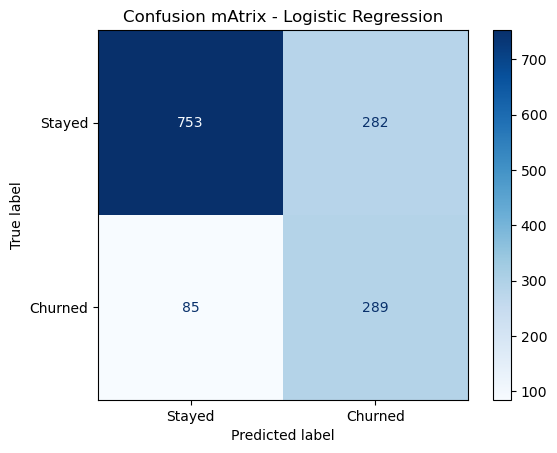


True Negatives  (predicted stayed, actually stayed): 753
False Positives (predicted churned, actually stayed): 282
False Negatives (predicted stayed, actually churned): 85
True Positives  (predicted churned, actually churned): 289


In [24]:
cm=confusion_matrix(y_test,y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stayed','Churned'])

disp.plot(cmap='Blues')
plt.title('Confusion mAtrix - Logistic Regression')
plt.show()
          
#Print the raw numbers

print("\nTrue Negatives  (predicted stayed, actually stayed):", cm[0][0])
print("False Positives (predicted churned, actually stayed):", cm[0][1])
print("False Negatives (predicted stayed, actually churned):", cm[1][0])
print("True Positives  (predicted churned, actually churned):", cm[1][1])


In [25]:
import pickle

#save model and scaler
with open('lr_model.pkl','wb') as f:
    pickle.dump(lr_model,f)

with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

print("Model saved as lr_model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as lr_model.pkl
Scaler saved as scaler.pkl
